# 02 — Exploratory Data Analysis

Wildfires Susceptibility Mapping — Córdoba, Argentina  
Input: `data/processed/dataset.csv` (72,296 × 24)

Sections:
1. Dataset overview & missing values
2. Label & spatial distribution
3. Feature distributions (fire vs. no-fire)
4. Correlation heatmap
5. Key findings

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.1)
PROCESSED = Path('../data/processed')
OUTPUTS   = Path('../outputs')
OUTPUTS.mkdir(exist_ok=True)

df = pd.read_csv(PROCESSED / 'dataset.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (72296, 24)


,lat,lon,label,month,land_cover_class,elevation,slope,aspect_cos,twi,ndvi,...,vpd,population_density,soc,clay,phh2o,bdod,distance_to_road_km,distance_to_river_km,distance_to_settlement_km,fire_season_flag
0,-33.719648,-64.681616,0,9,40.0,353.0,0.270543,-0.857058,17.597957,0.323275,...,9.566270,0.889648,118.000000,145.333333,67.0,133.666667,0.4592,2.9179,72.2923,1
1,-30.267707,-64.798635,0,9,20.0,231.0,0.289838,1.000000,17.566013,0.392985,...,15.012451,2.014913,99.666667,207.333333,72.0,135.333333,9.5894,15.6972,130.8947,1
2,-33.632001,-64.483284,0,9,40.0,318.0,0.181186,-0.639871,17.999891,0.366830,...,9.551730,1.101260,131.000000,152.333333,67.0,133.666667,4.3668,8.3530,57.0282,1


## 1. Dataset Overview & Missing Values

In [2]:
print('=== DTYPES & NULL COUNTS ===')
info = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info[info['null_count'] > 0])
print(f'\nTotal rows: {len(df):,}  |  Columns: {df.shape[1]}')

=== DTYPES & NULL COUNTS ===
                      dtype  null_count  null_pct
population_density  float64        2795      3.87

Total rows: 72,296  |  Columns: 24


In [3]:
df.describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
lat,72296.000000,-31.705436,1.399058,-34.998642,-32.690840,-31.502200,-30.454697,-29.508089
lon,72296.000000,-63.877152,0.946609,-65.776381,-64.644300,-63.957883,-63.057725,-61.787300
label,72296.000000,0.500000,0.500003,0.000000,0.000000,0.500000,1.000000,1.000000
month,72296.000000,8.640340,1.608024,1.000000,9.000000,9.000000,9.000000,12.000000
land_cover_class,72296.000000,38.390699,20.740915,20.000000,30.000000,40.000000,40.000000,126.000000
elevation,72296.000000,359.894185,353.247293,67.000000,124.000000,217.000000,460.000000,2670.000000
slope,72296.000000,0.905819,2.090180,0.000000,0.088508,0.205307,0.638422,35.171120
aspect_cos,72296.000000,0.138318,0.670311,-1.000000,-0.397697,0.027700,0.809417,1.000000
twi,72296.000000,17.612829,1.411426,12.611759,16.764665,17.894468,18.755677,19.194448
ndvi,72296.000000,0.353080,0.098982,-0.174062,0.318224,0.369059,0.409417,0.676685


## 2. Label Distribution & Spatial Map

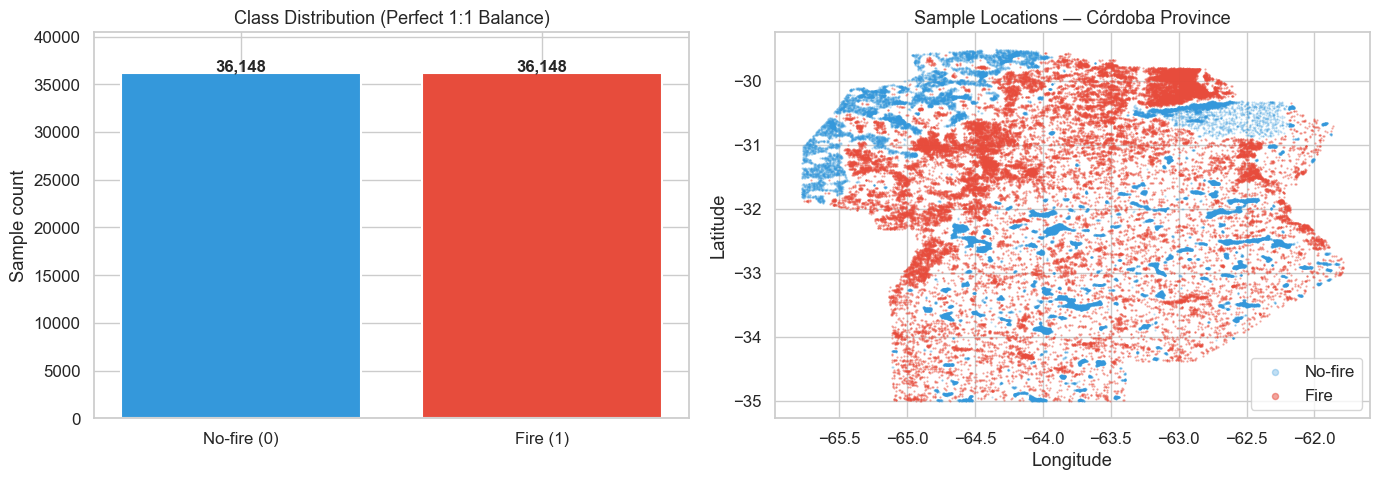

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Label bar chart ---
label_counts = df['label'].value_counts().sort_index()
axes[0].bar(['No-fire (0)', 'Fire (1)'], label_counts.values,
            color=['#3498db', '#e74c3c'], edgecolor='white', linewidth=1.5)
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution (Perfect 1:1 Balance)', fontsize=13)
axes[0].set_ylabel('Sample count')
axes[0].set_ylim(0, label_counts.max() * 1.12)
 
# --- Spatial map ---
fire   = df[df['label'] == 1]
nofire = df[df['label'] == 0]
axes[1].scatter(nofire['lon'], nofire['lat'], s=0.3, c='#3498db', alpha=0.3, label='No-fire')
axes[1].scatter(fire['lon'],   fire['lat'],   s=0.3, c='#e74c3c', alpha=0.5, label='Fire')
axes[1].set_title('Sample Locations — Córdoba Province', fontsize=13)
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
axes[1].legend(markerscale=8, loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUTS / 'eda_label_spatial.png', dpi=150, bbox_inches='tight')
plt.show()

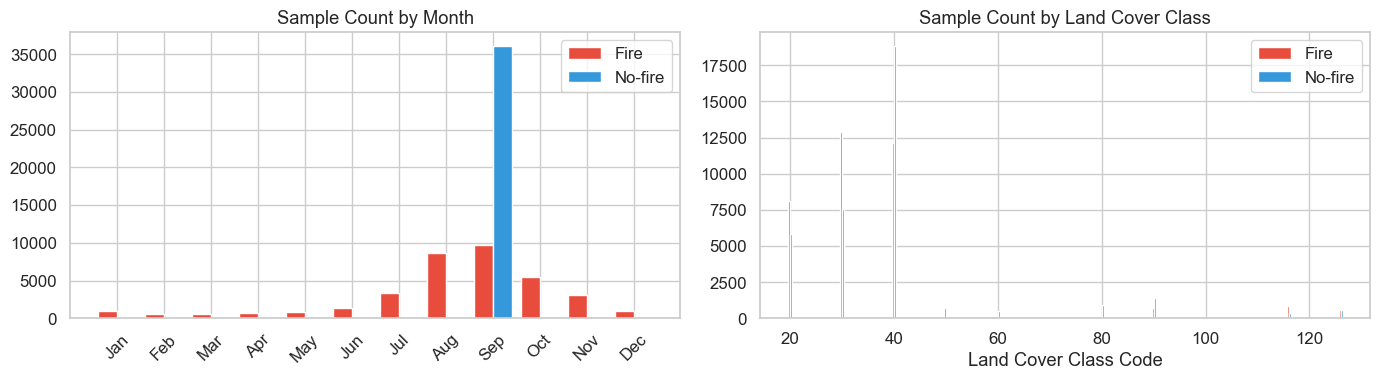

In [5]:
# Fire season distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

month_fire = df[df['label']==1]['month'].value_counts().sort_index()
month_nofire = df[df['label']==0]['month'].value_counts().sort_index()
x = range(1, 13)
axes[0].bar([m-0.2 for m in x], [month_fire.get(m, 0) for m in x],   0.4, label='Fire',    color='#e74c3c')
axes[0].bar([m+0.2 for m in x], [month_nofire.get(m, 0) for m in x], 0.4, label='No-fire', color='#3498db')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
axes[0].set_title('Sample Count by Month')
axes[0].legend()

# Land cover distribution
lc_fire   = df[df['label']==1]['land_cover_class'].value_counts().head(10)
lc_nofire = df[df['label']==0]['land_cover_class'].value_counts().head(10)
all_classes = sorted(set(lc_fire.index) | set(lc_nofire.index))
axes[1].bar([c-0.2 for c in all_classes], [lc_fire.get(c, 0) for c in all_classes],   0.4, label='Fire',    color='#e74c3c')
axes[1].bar([c+0.2 for c in all_classes], [lc_nofire.get(c, 0) for c in all_classes], 0.4, label='No-fire', color='#3498db')
axes[1].set_title('Sample Count by Land Cover Class')
axes[1].set_xlabel('Land Cover Class Code')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUTS / 'eda_temporal_landcover.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Distributions — Fire vs. No-fire

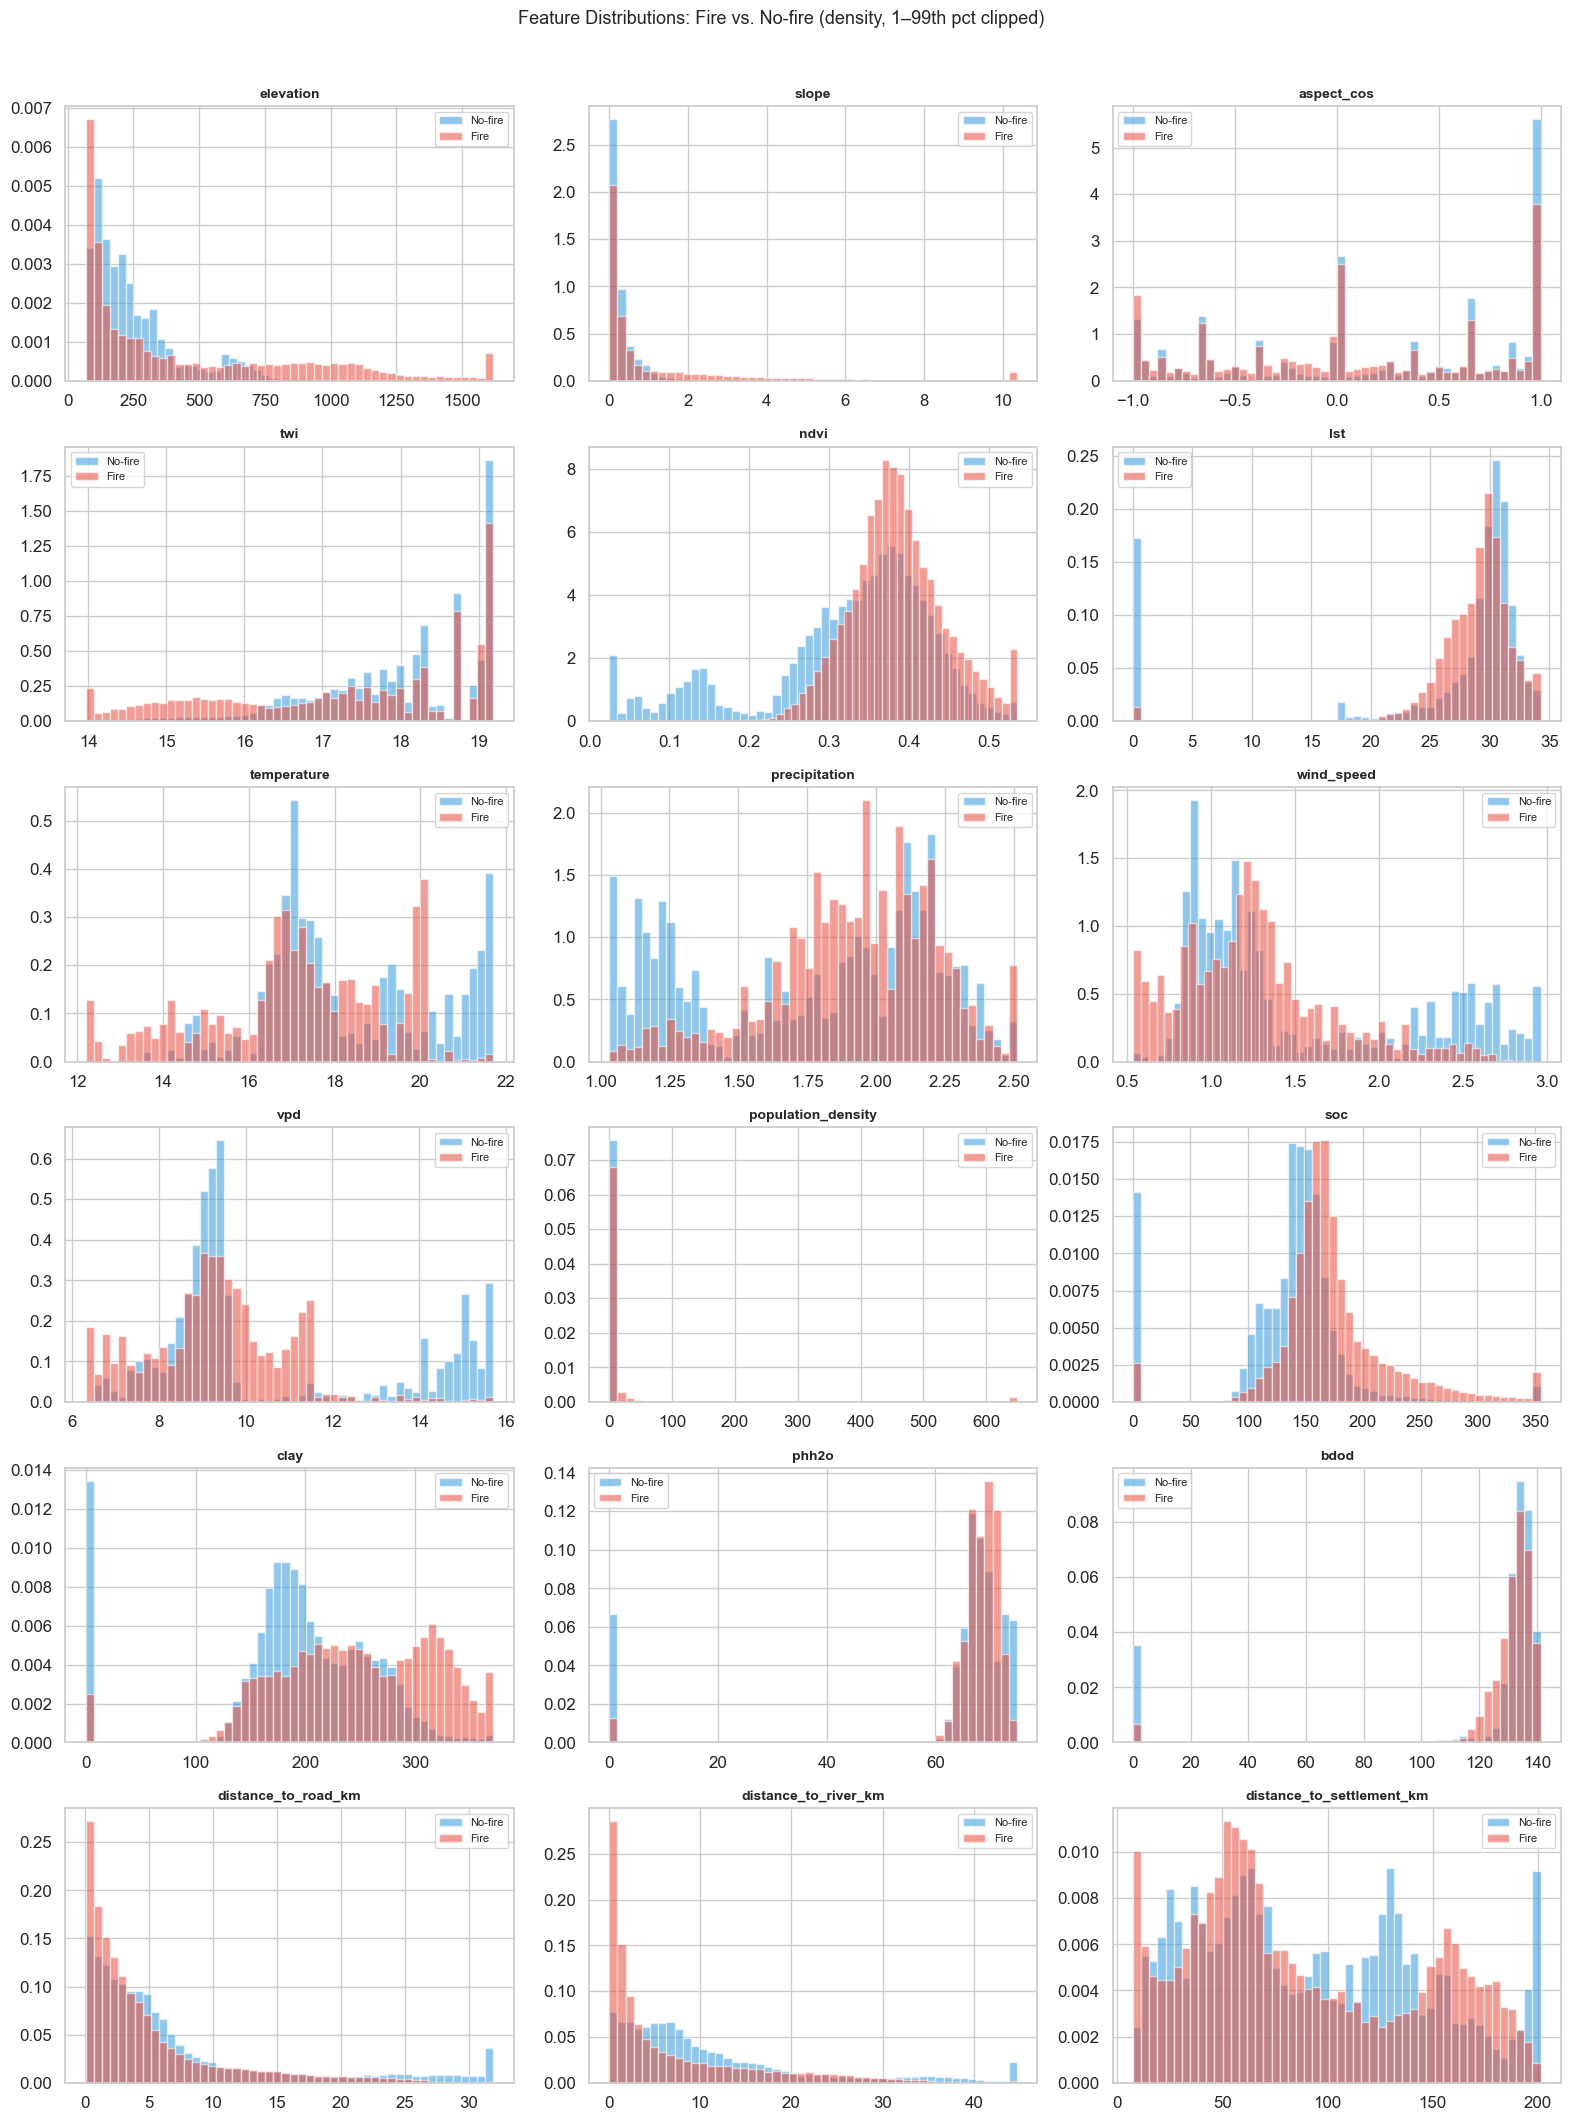

In [6]:
NUMERIC_FEATURES = [
    'elevation', 'slope', 'aspect_cos', 'twi',
    'ndvi', 'lst',
    'temperature', 'precipitation', 'wind_speed', 'vpd',
    'population_density',
    'soc', 'clay', 'phh2o', 'bdod',
    'distance_to_road_km', 'distance_to_river_km', 'distance_to_settlement_km'
]

fire_df   = df[df['label'] == 1]
nofire_df = df[df['label'] == 0]

ncols = 3
nrows = int(np.ceil(len(NUMERIC_FEATURES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(NUMERIC_FEATURES):
    ax = axes[i]
    vals_fire   = fire_df[feat].dropna()
    vals_nofire = nofire_df[feat].dropna()
    
    # Use percentile clipping for long tails
    lo = np.percentile(df[feat].dropna(), 1)
    hi = np.percentile(df[feat].dropna(), 99)
    
    ax.hist(vals_nofire.clip(lo, hi), bins=50, density=True, alpha=0.55,
            color='#3498db', label='No-fire')
    ax.hist(vals_fire.clip(lo, hi),   bins=50, density=True, alpha=0.55,
            color='#e74c3c', label='Fire')
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)

# Hide unused axes
for j in range(len(NUMERIC_FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Fire vs. No-fire (density, 1–99th pct clipped)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS / 'eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

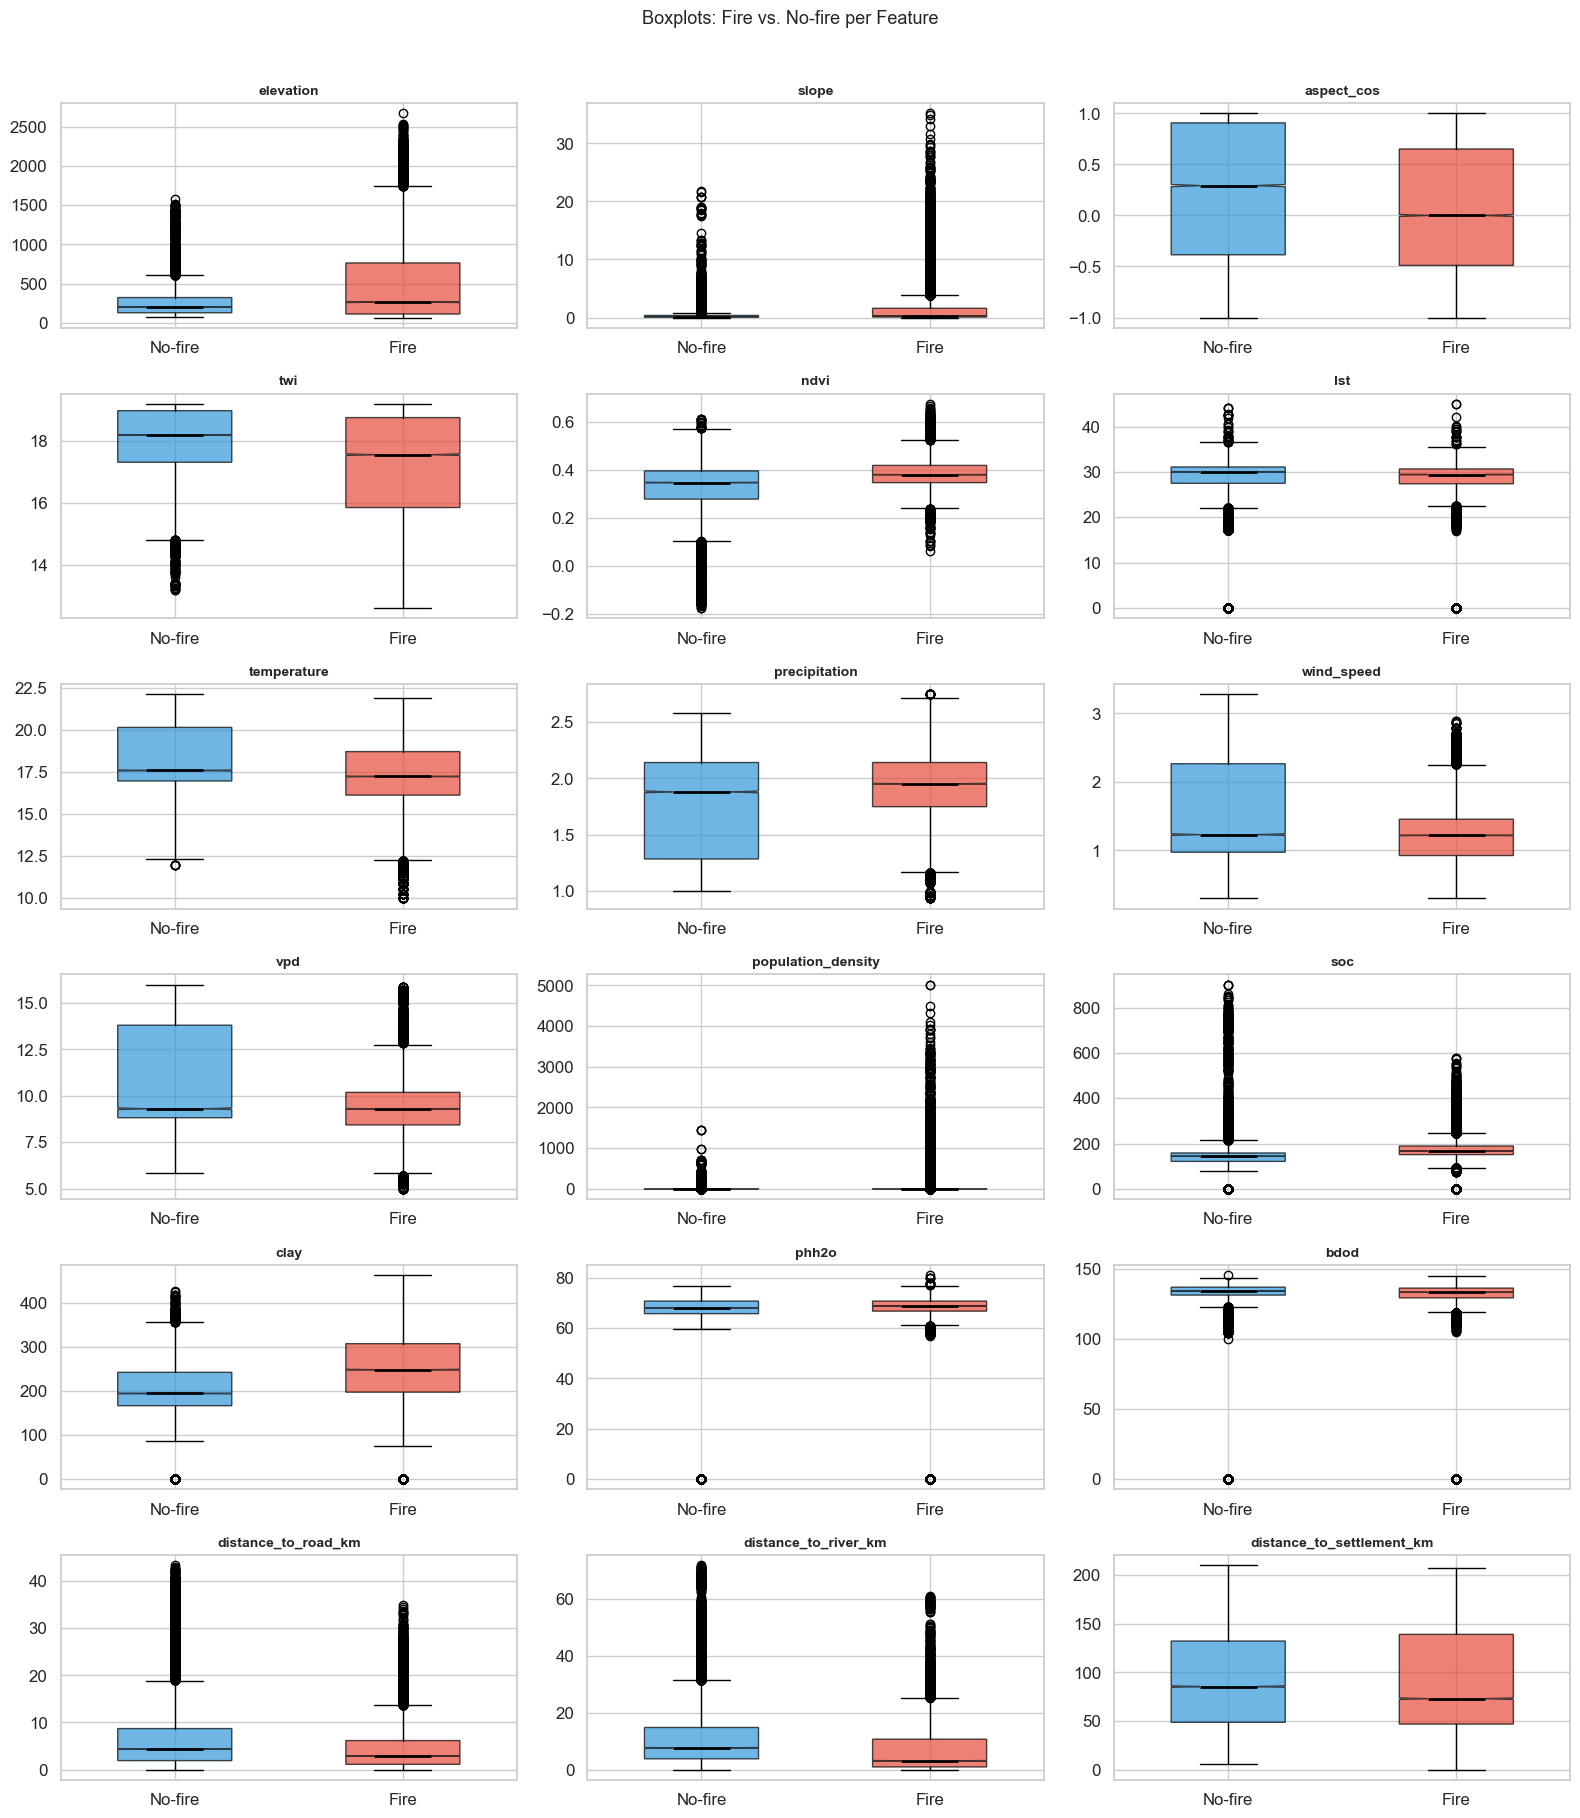

In [7]:
# Boxplot comparison — median shift between classes
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, feat in enumerate(NUMERIC_FEATURES):
    ax = axes[i]
    data = [nofire_df[feat].dropna(), fire_df[feat].dropna()]
    bp = ax.boxplot(data, patch_artist=True, notch=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#3498db', '#e74c3c']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['No-fire', 'Fire'])
    ax.set_title(feat, fontsize=10, fontweight='bold')

for j in range(len(NUMERIC_FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots: Fire vs. No-fire per Feature', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS / 'eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Summary stats by class
stats = df.groupby('label')[NUMERIC_FEATURES].median().T
stats.columns = ['No-fire (median)', 'Fire (median)']
stats['delta'] = stats['Fire (median)'] - stats['No-fire (median)']
stats['delta_pct'] = (stats['delta'] / stats['No-fire (median)'].abs().replace(0, np.nan) * 100).round(1)
stats.sort_values('delta_pct', key=abs, ascending=False)

,No-fire (median),Fire (median),delta,delta_pct
aspect_cos,0.292438,6.123234e-17,-0.292438,-100.0
slope,0.150533,2.898384e-01,0.139305,92.5
distance_to_river_km,7.678000,3.109000e+00,-4.569000,-59.5
distance_to_road_km,4.373550,2.882100e+00,-1.491450,-34.1
elevation,204.000000,2.630000e+02,59.000000,28.9
clay,194.333333,2.483333e+02,54.000000,27.8
population_density,0.789344,9.526135e-01,0.163270,20.7
soc,143.666667,1.660000e+02,22.333333,15.5
distance_to_settlement_km,85.442850,7.299445e+01,-12.448400,-14.6
ndvi,0.348425,3.814403e-01,0.033016,9.5


## 4. Correlation Heatmap

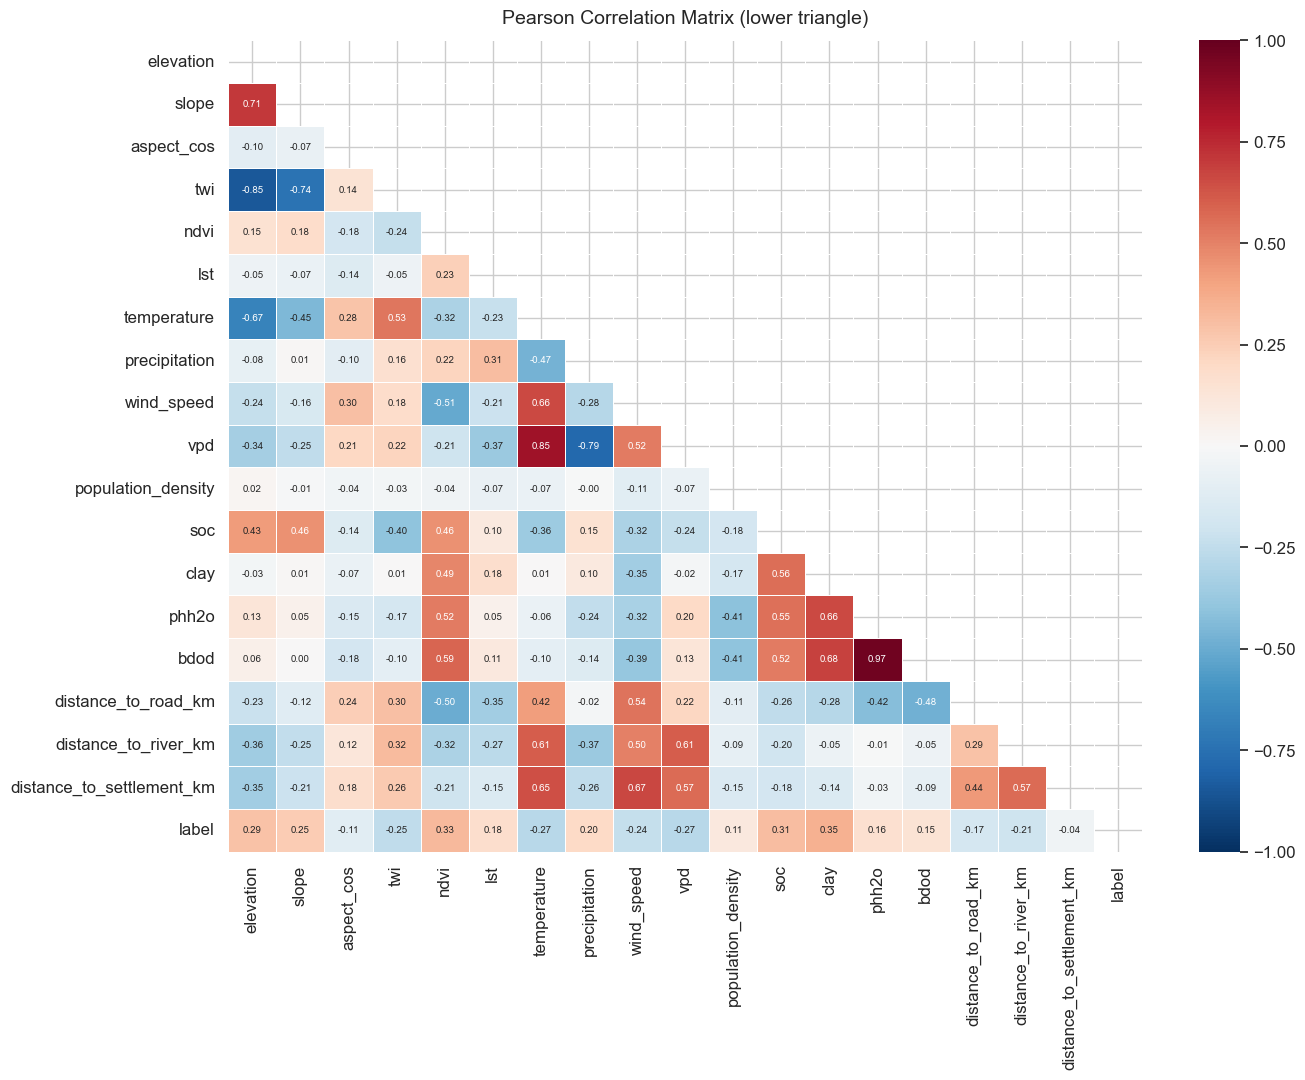

In [9]:
corr_features = NUMERIC_FEATURES + ['label']
corr = df[corr_features].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Pearson Correlation Matrix (lower triangle)', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig(OUTPUTS / 'eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# High-correlation pairs (|r| > 0.70) — candidates for Phase 3 filtering
high_corr = []
for col in NUMERIC_FEATURES:
    for row in NUMERIC_FEATURES:
        if col < row:  # upper triangle only
            r = corr.loc[row, col]
            if abs(r) > 0.70:
                high_corr.append({'feature_1': col, 'feature_2': row, 'r': round(r, 3)})

hc_df = pd.DataFrame(high_corr).sort_values('r', key=abs, ascending=False)
print(f'Pairs with |r| > 0.70: {len(hc_df)}')
hc_df

Pairs with |r| > 0.70: 6


,feature_1,feature_2,r
5,bdod,phh2o,0.973
3,temperature,vpd,0.850
1,elevation,twi,-0.847
4,precipitation,vpd,-0.789
2,slope,twi,-0.742
0,elevation,slope,0.710


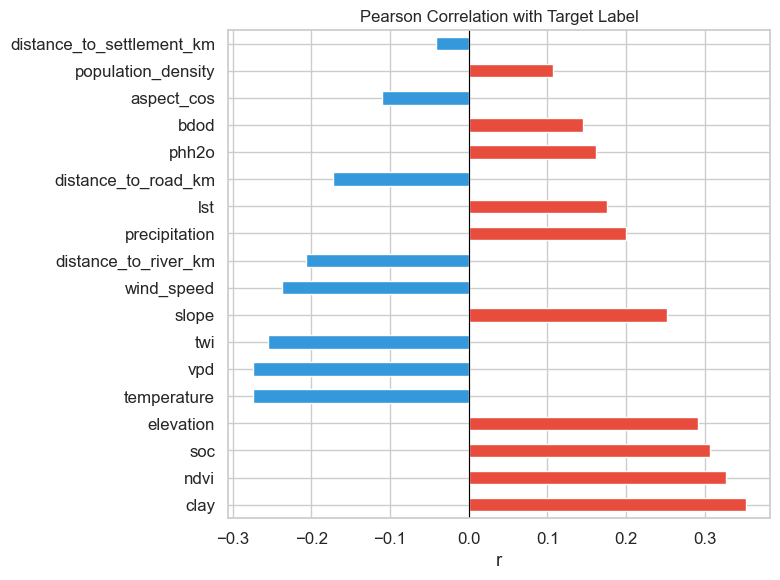

In [11]:
# Correlation with target label
target_corr = corr['label'].drop('label').sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr]
target_corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with Target Label', fontsize=12)
ax.set_xlabel('r')
plt.tight_layout()
plt.savefig(OUTPUTS / 'eda_target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Key Findings

Run this cell after executing all above cells.

In [12]:
print('=== EDA KEY FINDINGS ===')
print(f'  Total samples    : {len(df):,}  (fire={label_counts[1]:,}, no-fire={label_counts[0]:,})')
print(f'  Perfect balance  : {label_counts[1]/len(df)*100:.1f}% fire')
print(f'  population_density NaN: {df["population_density"].isnull().sum()} ({df["population_density"].isnull().mean()*100:.1f}%) → impute with median in Phase 3')
print()

top_target_corr = target_corr.abs().nlargest(5)
print('  Top 5 features correlated with label (|r|):')
for feat, val in top_target_corr.items():
    print(f'    {feat:<30}  r={target_corr[feat]:+.3f}')

print()
print(f'  High correlation pairs (|r|>0.70): {len(hc_df)}')
if len(hc_df):
    print('  Top pairs to watch in VIF/correlation filtering:')
    for _, row in hc_df.head(5).iterrows():
        print(f'    {row.feature_1} — {row.feature_2}  r={row.r:+.3f}')

=== EDA KEY FINDINGS ===
  Total samples    : 72,296  (fire=36,148, no-fire=36,148)
  Perfect balance  : 50.0% fire
  population_density NaN: 2795 (3.9%) → impute with median in Phase 3

  Top 5 features correlated with label (|r|):
    clay                            r=+0.352
    ndvi                            r=+0.327
    soc                             r=+0.307
    elevation                       r=+0.292
    temperature                     r=-0.274

  High correlation pairs (|r|>0.70): 6
  Top pairs to watch in VIF/correlation filtering:
    bdod — phh2o  r=+0.973
    temperature — vpd  r=+0.850
    elevation — twi  r=-0.847
    precipitation — vpd  r=-0.789
    slope — twi  r=-0.742
